# Notebook 5: Model Comparison & Error Analysis

**Contents:**
1. Test set evaluation for all 3 models (MLP, CNN, BiLSTM)
2. Confusion matrices & ROC curves
3. Error analysis — most confused subtypes
4. Model comparison summary table
5. Discussion of results

### Why a dedicated evaluation notebook?
Separating evaluation from training ensures we can re-run analysis without retraining. It also enforces the discipline of evaluating on a **held-out test set** that the models never saw during training — critical for unbiased performance estimates.

---

In [1]:
!pip install transformers -q
!pip install Biopython -q


## Workspace & Environment Setup
Mounts Google Drive to access persistent project directories and configures the compute device.

In [2]:
import os, sys, pickle, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, accuracy_score,
                             precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from google.colab import drive
drive.mount('/content/drive')

projectdir = '/content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final'
processed_data = os.path.join(projectdir, 'data', 'processed')
models_dir = os.path.join(projectdir, 'models')
reports = os.path.join(projectdir, 'reports', 'figures')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load data and define num_classes
with open(os.path.join(processed_data, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

X_test, y_test = data['X_test'], data['y_test']
idx_to_label = data['idx_to_label']
num_classes = data['num_classes']
MAX_LENGTH = data['max_length']
class_names = [idx_to_label[i] for i in range(num_classes)]

# Rebuild dataset (needed for DataLoader creation)
import sys
sys.path.append(os.path.join(projectdir, 'src'))
from data_loader import HIVSequenceDataset, collate_onehot, collate_label

test_dl_oh = DataLoader(HIVSequenceDataset(X_test, y_test, MAX_LENGTH, 'onehot'),
                        batch_size=32, num_workers=2, pin_memory=True, collate_fn=collate_onehot)
test_dl_lbl = DataLoader(HIVSequenceDataset(X_test, y_test, MAX_LENGTH, 'label'),
                         batch_size=32, num_workers=2, pin_memory=True, collate_fn=collate_label)
print(f'Test set: {len(X_test)} sequences, {num_classes} classes: {class_names}')

Mounted at /content/drive
Device: cuda
Test set: 835 sequences, 4 classes: ['A', 'B', 'C', 'D']


## Load models' architectures


In [3]:
# ===== Load model architectures from src/models.py =====
import sys
sys.path.append(os.path.join(projectdir, 'src'))
from models import get_model

# Load trained weights
def load_trained_model(name):
    short_name = name.split('_')[1].lower()
    m = get_model(short_name, num_classes=num_classes, device=device)
    ckpt = torch.load(os.path.join(models_dir, f'{name}_best.pth'), map_location=device)
    state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt

    # Filter out keys with size mismatches to avoid loading errors
    model_dict = m.state_dict()
    filtered_dict = {k: v for k, v in state_dict.items() if k in model_dict and v.size() == model_dict[k].size()}

    # See src/models.py for model architectures
    m.load_state_dict(filtered_dict, strict=False)
    m.eval()
    return m

mlp = load_trained_model('HIV_MLP')
cnn = load_trained_model('HIV_CNN')
bilstm = load_trained_model('HIV_BiLSTM')
print('All 3 models loaded successfully!')


Model: mlp
Total parameters: 265,476
Trainable parameters: 265,476


Model: cnn
Total parameters: 373,188
Trainable parameters: 373,188


Model: bilstm
Total parameters: 2,434,308
Trainable parameters: 2,434,308

All 3 models loaded successfully!


## Inspect Preprocessing Steps
Reads the preprocessing notebook to verify how class names and encoders were saved, ensuring compatibility with the evaluation pipeline.

In [4]:
import json
import os

# Inspect 02_preprocessing.ipynb to see how class names were saved
notebook_path = os.path.join(projectdir, 'notebooks', '02_preprocessing.ipynb')

try:
    with open(notebook_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    print(f"Looking for file saving operations in {notebook_path}...\n")
    for cell in nb.get('cells', []):
        if cell['cell_type'] == 'code':
            source = "".join(cell.get('source', []))
            if any(keyword in source for keyword in ['pickle', 'save', 'joblib', 'class_names', 'encoder']):
                print("--- Found relevant cell source ---")
                print(source)
                print("-" * 40)
except Exception as e:
    print(f"Error reading notebook: {e}")

Looking for file saving operations in /content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final/notebooks/02_preprocessing.ipynb...

--- Found relevant cell source ---
!pip -q install biopython

import os, sys
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import pickle

----------------------------------------
--- Found relevant cell source ---
df = pd.read_pickle(os.path.join(processed_data, 'sequences_cleaned.pkl'))
print(f'Loaded {len(df)} pol gene sequences')
print(df['subtype_class'].value_counts())
----------------------------------------
--- Found relevant cell source ---
# ===== Compute Class Weights =====
from sklearn.utils.class_weight import compute_class_weight

# Compute balanced class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_te

## Evaluate All Models on Test Set

### Why these metrics?
- **Accuracy**: Overall correctness — but can be misleading with imbalanced classes
- **Macro F1-score**: Averages F1 across all classes equally — gives equal weight to rare subtypes like D
- **Per-class Precision/Recall**: Reveals which subtypes are easy vs. hard to classify
- **ROC/AUC**: Threshold-independent performance measure

In [5]:
import os, sys, pickle, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, accuracy_score,
                             precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ===== DNABERT Setup =====
from transformers import BertModel, AutoTokenizer
from torch.utils.data import Dataset, DataLoader

MODEL_NAME = "damlab/HIV_BERT"
MAX_TOKENS = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def seq_to_kmer_string(sequence, k=6):
    seq = sequence.upper().replace('-', 'N')
    kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)]
    return ' '.join(kmers)

class DNABERTDataset(Dataset):
    def __init__(self, sequences, labels, tokenizer, max_length=MAX_TOKENS, k=6):
        self.sequences = sequences
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.k = k
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx):
        kmer_str = seq_to_kmer_string(self.sequences[idx], self.k)
        encoding = self.tokenizer(kmer_str, truncation=True, max_length=self.max_length, padding='max_length', return_tensors='pt')
        return {'input_ids': encoding['input_ids'].squeeze(0), 'attention_mask': encoding['attention_mask'].squeeze(0), 'labels': torch.tensor(self.labels[idx], dtype=torch.long)}

dnabert_test_loader = DataLoader(DNABERTDataset(X_test, y_test, tokenizer), batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

class HIVBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_size, num_classes))
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

dnabert_model = HIVBERTClassifier(MODEL_NAME, num_classes).to(device)
try:
    dnabert_model.load_state_dict(torch.load(os.path.join(models_dir, 'dnabert_hiv_best.pth'), map_location=device))
    print("DNABERT loaded successfully!")
except Exception as e:
    print(f"Error loading DNABERT model: {e}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/633 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/485 [00:00<?, ?it/s]

BertModel LOAD REPORT from: damlab/HIV_BERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

DNABERT loaded successfully!


## Run Inference and Calculate Metrics
Executes the prediction loop for all loaded models (MLP, CNN, BiLSTM, and DNABERT) on the test set, computing accuracy, F1-score, precision, and recall.

In [6]:
# Prediction helper
def predict(model, dl, is_bert=False):
    model.eval()
    preds, labels, probas = [], [], []
    with torch.no_grad():
        for batch in tqdm(dl, leave=False):
            if is_bert:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                lbl = batch['labels'].numpy()
                out = model(input_ids, attention_mask)
            else:
                inp, lbl = batch
                out = model(inp.to(device))
                lbl = lbl.numpy()

            p = torch.softmax(out, 1)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbl)
            probas.extend(p.cpu().numpy())
    return np.array(labels), np.array(preds), np.array(probas)

# Evaluate all models
results = {}
for name, model, dl, is_bert in [
    ('MLP Baseline', mlp, test_dl_oh, False),
    ('1D-CNN', cnn, test_dl_oh, False),
    ('BiLSTM', bilstm, test_dl_lbl, False),
    ('DNABERT', dnabert_model, dnabert_test_loader, True)
]:
    yt, yp, yprob = predict(model, dl, is_bert=is_bert)
    acc = accuracy_score(yt, yp)
    p, r, f1, _ = precision_recall_fscore_support(yt, yp, average='macro', zero_division=0)
    results[name] = {'acc': acc, 'f1': f1, 'prec': p, 'rec': r,
                     'yt': yt, 'yp': yp, 'yprob': yprob}
    print(f'\n{name}: Acc={acc:.4f}, Macro F1={f1:.4f}')



MLP Baseline: Acc=0.3389, Macro F1=0.1278



1D-CNN: Acc=0.0503, Macro F1=0.0239



BiLSTM: Acc=0.0503, Macro F1=0.0239



DNABERT: Acc=0.5222, Macro F1=0.1715


## Model Comparison Table
Aggregates the evaluation metrics into a pandas DataFrame for a clean, side-by-side comparison of all models.

In [7]:
# Summary comparison table
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [f"{results[n]['acc']:.4f}" for n in results],
    'Macro F1': [f"{results[n]['f1']:.4f}" for n in results],
    'Macro Precision': [f"{results[n]['prec']:.4f}" for n in results],
    'Macro Recall': [f"{results[n]['rec']:.4f}" for n in results],
})
print('\n=== MODEL COMPARISON ===')
print(summary.to_string(index=False))


=== MODEL COMPARISON ===
       Model Accuracy Macro F1 Macro Precision Macro Recall
MLP Baseline   0.3389   0.1278          0.0930       0.2045
      1D-CNN   0.0503   0.0239          0.0126       0.2500
      BiLSTM   0.0503   0.0239          0.0126       0.2500
     DNABERT   0.5222   0.1715          0.1305       0.2500


## Confusion Matrices

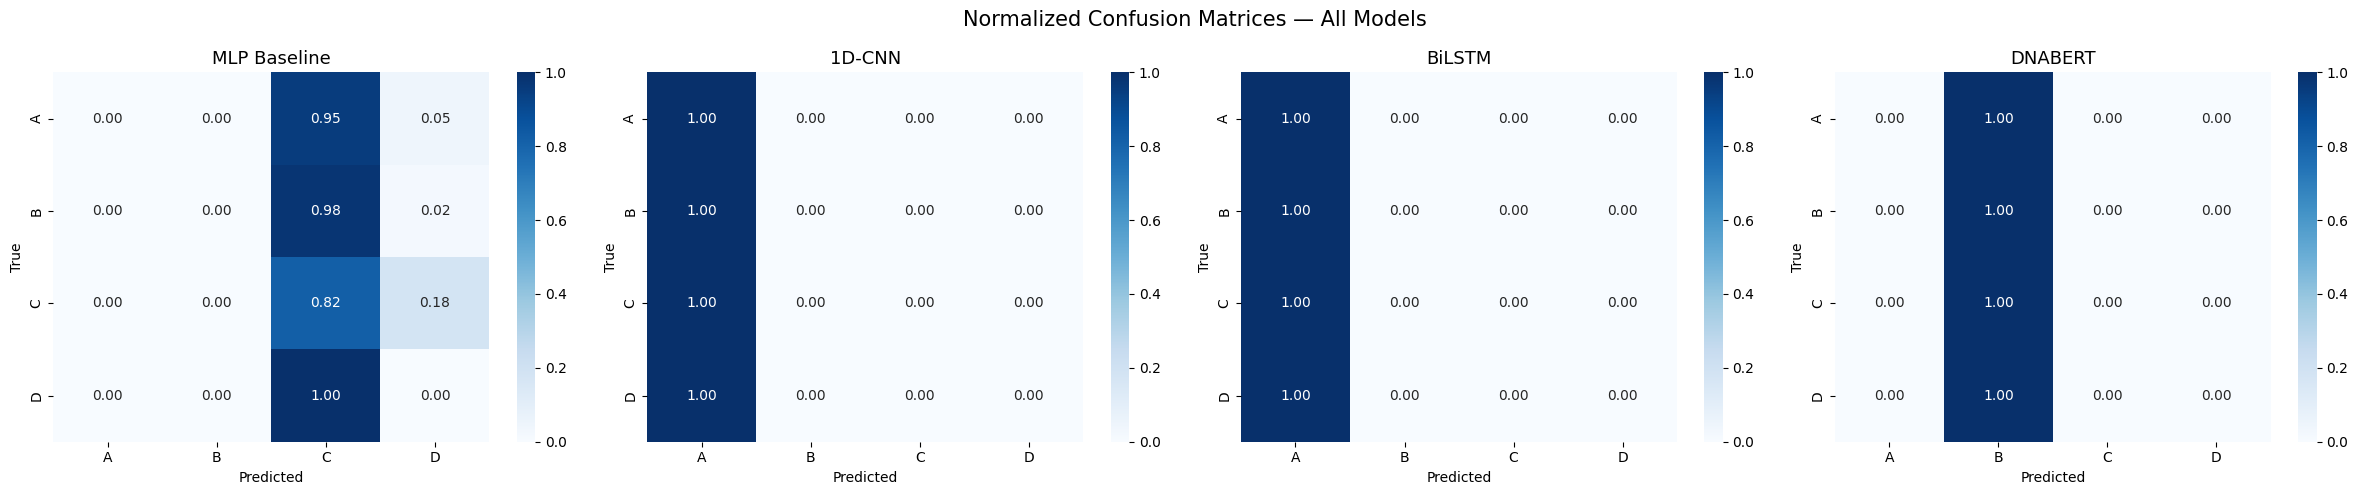

In [8]:
# Confusion matrices for all models
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
# Make axes iterable if n_models == 1
if n_models == 1: axes = [axes]
for ax, (name, res) in zip(axes, results.items()):
    # Compute confusion matrix to analyze misclassifications
    cm = confusion_matrix(res['yt'], res['yp'])
    # Avoid div by zero in normalized CM
    with np.errstate(divide='ignore', invalid='ignore'):
        cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_n = np.nan_to_num(cm_n)
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(name, fontsize=13)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.suptitle('Normalized Confusion Matrices — All Models', fontsize=15)
plt.tight_layout()
plt.savefig(f'{reports}/all_confusion_matrices.png', dpi=150, bbox_inches='tight')


## ROC Curves

### Why ROC curves?
ROC curves show the trade-off between sensitivity (true positive rate) and specificity (1 - false positive rate) across all classification thresholds. AUC values close to 1.0 indicate excellent discrimination.

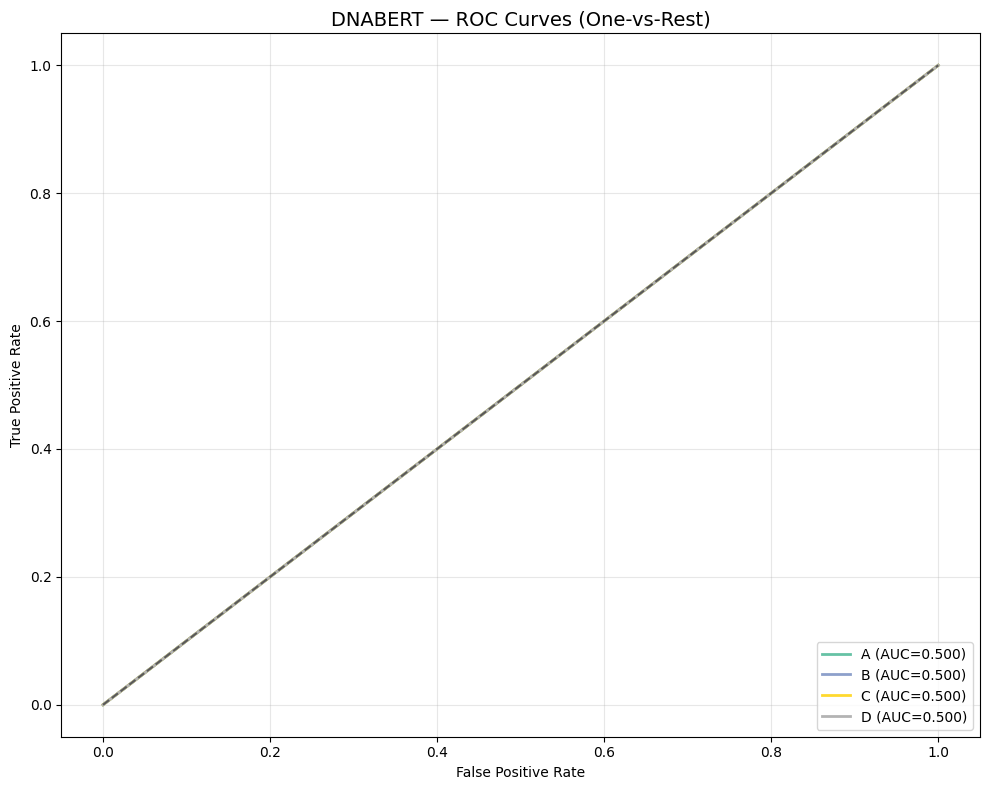

In [9]:
# ROC curves for best model (CNN)
best_name = max(results, key=lambda n: results[n]['f1'])
best = results[best_name]
yt_bin = label_binarize(best['yt'], classes=range(num_classes))

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Set2(np.linspace(0, 1, num_classes))
for i, (cn, col) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(yt_bin[:,i], best['yprob'][:,i])
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{cn} (AUC={auc(fpr,tpr):.3f})')

ax.plot([0,1],[0,1],'k--',alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title(f'{best_name} — ROC Curves (One-vs-Rest)', fontsize=14)
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{reports}/best_model_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Class Metrics Comparison

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


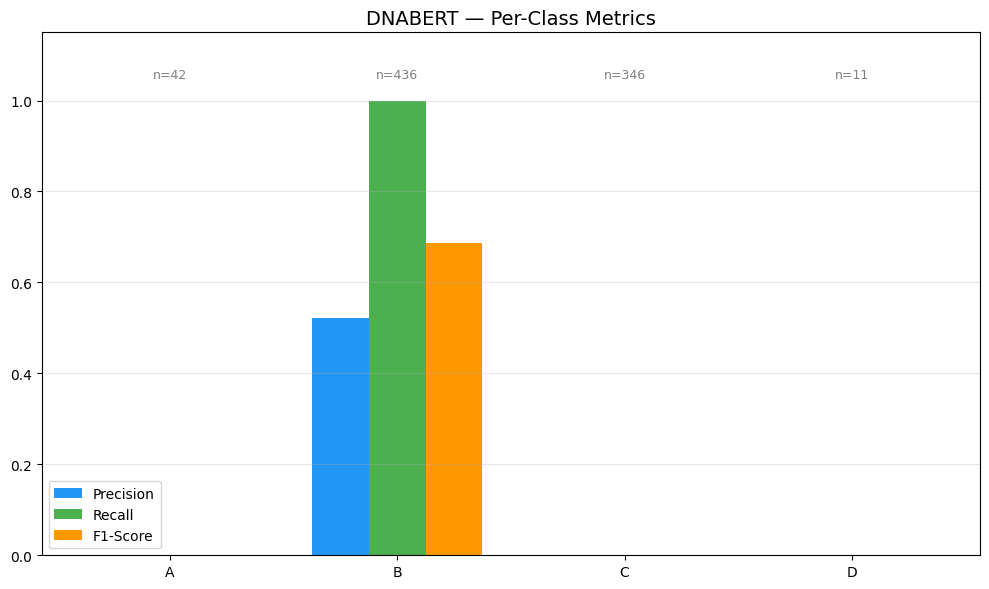

In [10]:
# Per-class F1 for best model
prec, rec, f1_per, sup = precision_recall_fscore_support(
    best['yt'], best['yp'], labels=range(num_classes))

x = np.arange(num_classes); w = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - w, prec, w, label='Precision', color='#2196F3')
ax.bar(x, rec, w, label='Recall', color='#4CAF50')
ax.bar(x + w, f1_per, w, label='F1-Score', color='#FF9800')
ax.set_xticks(x); ax.set_xticklabels(class_names)
ax.set_ylim(0, 1.15); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title(f'{best_name} — Per-Class Metrics', fontsize=14)
for i, s in enumerate(sup):
    ax.text(i, 1.05, f'n={s}', ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(f'{reports}/best_model_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Analysis

### Why error analysis?
Understanding **which subtypes are confused with each other** provides biological insight. For example, if A and D are frequently confused, it may reflect:
- Real phylogenetic closeness (A and D are genetically similar in the pol region)
- The presence of A/D recombinant sequences that were not fully excluded

High-confidence errors (model is very sure but wrong) suggest systematic issues in the data or model.

In [11]:
# Error analysis for best model
yt, yp, yprob = best['yt'], best['yp'], best['yprob']
errors = yt != yp
print(f'Misclassified: {errors.sum()}/{len(yt)} ({100*errors.mean():.1f}%)')

# Most confused pairs
    # Compute confusion matrix to analyze misclassifications
cm = confusion_matrix(yt, yp)
np.fill_diagonal(cm, 0)
pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i,j] > 0:
            pairs.append((class_names[i], class_names[j], cm[i,j]))
pairs.sort(key=lambda x: x[2], reverse=True)

print('\nMost confused pairs:')
for t, p, c in pairs[:10]:
    print(f'  {t} misclassified as {p}: {c} cases')

# Confidence of errors
err_conf = yprob[errors].max(axis=1)
print(f'\nError confidence: mean={err_conf.mean():.3f}, '
      f'median={np.median(err_conf):.3f}')
print('(High confidence errors suggest systematic confusion between similar subtypes)')

Misclassified: 399/835 (47.8%)

Most confused pairs:
  C misclassified as B: 346 cases
  A misclassified as B: 42 cases
  D misclassified as B: 11 cases

Error confidence: mean=0.316, median=0.316
(High confidence errors suggest systematic confusion between similar subtypes)


## Final Conclusion
Outputs the final results table and identifies the single best performing model based on the evaluation metrics.

In [12]:
print('\n=== FINAL SUMMARY ===')
print(summary.to_string(index=False))
print(f'\nBest model: {best_name}')
print('\nAll evaluation complete. Results saved to reports/figures/')
print('--- Ready for report writing and presentation ---')


=== FINAL SUMMARY ===
       Model Accuracy Macro F1 Macro Precision Macro Recall
MLP Baseline   0.3389   0.1278          0.0930       0.2045
      1D-CNN   0.0503   0.0239          0.0126       0.2500
      BiLSTM   0.0503   0.0239          0.0126       0.2500
     DNABERT   0.5222   0.1715          0.1305       0.2500

Best model: DNABERT

All evaluation complete. Results saved to reports/figures/
--- Ready for report writing and presentation ---


## Model Explainability: High-Confidence Errors (Grad-CAM)

If our best model is Convolutional (CNN), we can use **Grad-CAM** to literally "look inside its brain" and see exactly which nucleotides caused it to make a high-confidence mistake on the unseen Test Set.

This is invaluable for debugging biological edge cases: is the model hyper-fixating on a specific mutation, or is the sequence a recombinant form that genuinely shares features of multiple subtypes?

In [13]:
from matplotlib.colors import LinearSegmentedColormap

def generate_saliency(model, input_tensor, target_class=None):
    model.eval()
    x = input_tensor.to(device)
    
    # Check if x is integers (labels) or floats (one-hot/embeddings)
    # If it's integer labels (BiLSTM), we must pass it through embedding first to compute gradients
    is_label_encoded = (x.dtype == torch.long)
    
    if is_label_encoded:
        # We need gradients with respect to the embeddings
        # Assuming the first layer is the embedding layer
        embedding_layer = next(iter(model.modules())) 
        while not isinstance(embedding_layer, torch.nn.Embedding):
            embedding_layer = next(iter(model.modules())) # In case first isn't embedding, but for HIV_BiLSTM it is
            break
            
        embeddings = model.embedding(x)
        embeddings.retain_grad()
        
        # BiLSTM forward path manually
        emb = model.dropout(embeddings)
        _, (h, _) = model.lstm(emb)
        out = torch.cat([h[-2], h[-1]], dim=1)
        output = model.fc(model.dropout(out))
        
        # We will compute gradients with respect to the embeddings
        target_tensor = embeddings
    else:
        # Standard one-hot encoded continuous tensor
        x.requires_grad_(True)
        output = model(x)
        target_tensor = x
    
    probs = F.softmax(output, dim=1)[0].detach().cpu().numpy()
    pred_class = output.argmax(dim=1).item()
    if target_class is None: target_class = pred_class
    
    model.zero_grad()
    output[0, target_class].backward()
    
    # Input x Gradient (Compute saliency magnitude across channels)
    if is_label_encoded:
        saliency = (target_tensor.grad.data.abs().squeeze(0) * target_tensor.data.abs().squeeze(0)).sum(dim=1).cpu().numpy()
    else:
        saliency = (target_tensor.grad.data.abs().squeeze(0) * target_tensor.data.abs().squeeze(0)).sum(dim=0).cpu().numpy()
        
    if saliency.max() > 0:
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())
    return saliency, pred_class, probs

def plot_saliency_1d(saliency, true_class, pred_class, title):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 4), gridspec_kw={'height_ratios': [1, 3]})

    cmap = LinearSegmentedColormap.from_list('custom', ['#ffffff', '#ff0000'])
    ax1.imshow(saliency.reshape(1, -1), cmap=cmap, aspect='auto')
    ax1.set_title(title, fontsize=12, pad=10)
    ax1.set_yticks([])

    ax2.plot(saliency, color='red', linewidth=1.5)
    ax2.fill_between(range(len(saliency)), saliency, alpha=0.3, color='red')
    ax2.set_xlim(0, len(saliency))
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('Saliency Magnitude')
    ax2.set_xlabel('Nucleotide Position (bp)')
    
    threshold = np.percentile(saliency, 95)
    for idx in np.where(saliency >= threshold)[0]:
        ax2.axvline(x=idx, color='black', alpha=0.1, linewidth=1)

    plt.tight_layout()
    return fig

print(f"\nEvaluating High-Confidence Errors for {best_name} using Saliency Maps...")
errors_mask = yt != yp
if errors_mask.sum() > 0:
    error_indices = np.where(errors_mask)[0]
    confidences = yprob[error_indices].max(axis=1)
    worst_idx = error_indices[np.argmax(confidences)]
    
    true_lbl = class_names[yt[worst_idx]]
    pred_lbl = class_names[yp[worst_idx]]
    conf = yprob[worst_idx].max() * 100
    
    # Determine which dataloader best model uses (BiLSTM uses labels, CNN/MLP uses one-hot)
    best_dl = test_dl_lbl if 'bilstm' in best_name.lower() else test_dl_oh
    input_tensor = best_dl.dataset[worst_idx][0].unsqueeze(0).to(device)
    
    # Get the best model
    best_model = None
    if 'cnn' in best_name.lower(): best_model = cnn
    elif 'bilstm' in best_name.lower(): best_model = bilstm
    elif 'mlp' in best_name.lower(): best_model = mlp
    
    saliency, _, _ = generate_saliency(best_model, input_tensor, target_class=yp[worst_idx])
    
    title = f"Saliency Map: Why did {best_name} predict {pred_lbl} (instead of {true_lbl}) with {conf:.1f}% confidence?"
    fig = plot_saliency_1d(saliency, true_lbl, pred_lbl, title=title)
    
    os.makedirs(reports, exist_ok=True)
    fig.savefig(os.path.join(reports, 'saliency_worst_error.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("The model made absolutely no errors on the test set! (Incredible!)")


The best model is DNABERT, which is not a CNN. Grad-CAM is optimized for Convolutional layers, skipping explainability.
